<a href="https://colab.research.google.com/github/st4rfruit/detect/blob/main/rfdetr_sahi_inference_groundtruth_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U transformers -q
!pip install supervision -q
!pip install 'sahi[roboflow]==0.11.36' -q
!pip uninstall -y onnxruntime onnxruntime-gpu -q
!pip install 'onnxruntime-gpu==1.19.2' -q
print('Done — restart runtime if this is the first run')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 132.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.3/373.3 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 18.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 11.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━

## Local Inference on GPU
Model page: https://huggingface.co/MBARI-org/mbari-uav-vit-b-16

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/MBARI-org/mbari-uav-vit-b-16)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [1]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("image-classification", model="MBARI-org/mbari-uav-vit-b-16")
pipe("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/hub/parrots.png")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

[{'label': 'Bird', 'score': 0.9044660925865173},
 {'label': 'Boat', 'score': 0.07442564517259598},
 {'label': 'Foam', 'score': 0.016268545761704445},
 {'label': 'Wave', 'score': 0.0009768339805305004},
 {'label': 'Reflectance', 'score': 0.0008462496334686875}]

In [2]:
# Load model directly
from transformers import AutoImageProcessor, AutoModelForImageClassification

processor = AutoImageProcessor.from_pretrained("MBARI-org/mbari-uav-vit-b-16")
model = AutoModelForImageClassification.from_pretrained("MBARI-org/mbari-uav-vit-b-16")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [3]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [4]:
# Allow access to personal google drive and add new folders

# Connect Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True) # This will prompt for authorization.

# This will create the uavs files if they don't exist.
folders =  ["rfdetr-backgrounds/"]
for folder in folders:
  path = "/content/drive/MyDrive/" + folder
  if not os.path.exists(path): # Create the folder if it does not exist
    os.mkdir(path)

Mounted at /content/drive


In [5]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets
from google.colab import userdata

!cp "/content/drive/MyDrive/rfdetr-backgrounds/onnx_export5/rfdetr-medium.onnx" "/content/rfdetr-medium.onnx"

# Point these at the specific image + YOLO label file to run on, directly on Drive
# (no extraction / copying needed — read straight from the mounted Drive path).

# otter image
# IMAGE_PATH = "/content/drive/MyDrive/rfdetr-backgrounds/trinity-2_20231109T191204_DSC05272.JPG"
# LABEL_PATH = "/content/drive/MyDrive/rfdetr-backgrounds/trinity-2_20231109T191204_DSC05272.txt"

# buoy image
IMAGE_PATH = "/content/drive/MyDrive/rfdetr-backgrounds/trinity-1_20230607T194614_DSC00188.JPG"
LABEL_PATH = "/content/drive/MyDrive/rfdetr-backgrounds/trinity-1_20230607T194614_DSC00188.txt"

assert os.path.exists(IMAGE_PATH), f"Image not found: {IMAGE_PATH}"
assert os.path.exists(LABEL_PATH), f"Label file not found: {LABEL_PATH}"

/content/datasets


In [6]:
## Load the requested image and its ground-truth YOLO labels

import numpy as np
import supervision as sv
from PIL import Image

# One class name per line; line N (0-indexed) = class id N.
_labels_txt_path = '/content/drive/MyDrive/rfdetr-backgrounds/labels.txt'
if os.path.exists(_labels_txt_path):
    with open(_labels_txt_path) as f:
        DETECTOR_CLASSES = f.read().splitlines()
    print(f'Detector classes ({len(DETECTOR_CLASSES)}): {DETECTOR_CLASSES}')
else:
    DETECTOR_CLASSES = None
    print('labels.txt not found — GT boxes will show class IDs')

# Load YOLO ground truth for the requested image.
def load_yolo_gt(lbl_path, img_w, img_h):
    if not os.path.exists(lbl_path):
        print(f'No label file found: {lbl_path}')
        return sv.Detections.empty()
    xyxy, class_ids = [], []
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = max(0.0, (cx - bw / 2) * img_w)
            y1 = max(0.0, (cy - bh / 2) * img_h)
            x2 = min(float(img_w), (cx + bw / 2) * img_w)
            y2 = min(float(img_h), (cy + bh / 2) * img_h)
            xyxy.append([x1, y1, x2, y2])
            class_ids.append(cls_id)
    if not xyxy:
        return sv.Detections.empty()
    return sv.Detections(
        xyxy=np.array(xyxy, dtype=np.float32),
        class_id=np.array(class_ids, dtype=int),
    )

image_pil = Image.open(IMAGE_PATH).convert('RGB')
img_w, img_h = image_pil.size
gt = load_yolo_gt(LABEL_PATH, img_w, img_h)
print(f'Ground truth boxes: {len(gt)}')

Detector classes (20): ['Batray', 'Fish', 'Kelp', 'Egregia', 'FalseBatray', 'Bird', 'Mola', 'Buoy', 'Jelly', 'Velella_velella', 'Cement_Ship', 'Boat', 'Shark', 'Pinniped', 'Kayak', 'Person', 'Otter', 'Velella_velella_raft', 'Surfboard', 'Whale']
Ground truth boxes: 1


In [7]:
## Load ONNX detector via custom SAHI DetectionModel, load ViT classifier

import torch, numpy as np, onnxruntime as ort, supervision as sv
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sahi.models.base import DetectionModel
from sahi.prediction import ObjectPrediction
from sahi.predict import get_sliced_prediction

ONNX_MODEL_PATH      = '/content/rfdetr-medium.onnx'
CONFIDENCE_THRESHOLD = 0.50
IMAGE_SIZE           = 576   # model training resolution
SLICE_SIZE           = 576   # match training resolution
OVERLAP              = 0.20
DEVICE               = 'cuda' if torch.cuda.is_available() else 'cpu'


class RFDetrOnnxDetectionModel(DetectionModel):
    """SAHI-compatible wrapper for RF-DETR exported as ONNX.
    ONNX outputs:
      dets:   [1, 300, 4]  normalised cx,cy,w,h
      labels: [1, 300, 1]  raw logits (sigmoid → confidence)
    """

    def load_model(self):
        providers = (
            ['CUDAExecutionProvider', 'CPUExecutionProvider']
            if torch.cuda.is_available() else ['CPUExecutionProvider']
        )
        self.session      = ort.InferenceSession(self.model_path, providers=providers)
        self.input_name   = self.session.get_inputs()[0].name
        self.output_names = [o.name for o in self.session.get_outputs()]
        print(f'Active provider : {self.session.get_providers()[0]}')
        print(f'ONNX inputs     : {self.input_name}')
        print(f'ONNX outputs    : {self.output_names}')
        self.model = self.session

    def perform_inference(self, image: np.ndarray):
        h, w = image.shape[:2]
        tile = Image.fromarray(image).resize((self.image_size, self.image_size), Image.BILINEAR)
        tile = np.array(tile, dtype=np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        tile = ((tile - mean) / std).transpose(2, 0, 1)[None]
        self._original_predictions = self.session.run(self.output_names, {self.input_name: tile})
        self._tile_hw = (h, w)

    def convert_original_predictions(self, shift_amount=None, full_shape=None):
        if shift_amount is None:
            shift_amount = [0, 0]

        dets   = self._original_predictions[0][0]   # [300, 4]
        labels = self._original_predictions[1][0]   # [300, 1]
        tile_h, tile_w = self._tile_hw
        scores = 1.0 / (1.0 + np.exp(-labels[:, 0]))

        object_prediction_list = []
        for box, score in zip(dets, scores):
            if score < self.confidence_threshold:
                continue
            cx, cy, bw, bh = box
            x1 = (cx - bw / 2) * tile_w
            y1 = (cy - bh / 2) * tile_h
            x2 = (cx + bw / 2) * tile_w
            y2 = (cy + bh / 2) * tile_h
            x1, y1 = max(0.0, x1), max(0.0, y1)
            x2, y2 = min(float(tile_w), x2), min(float(tile_h), y2)
            if x2 <= x1 or y2 <= y1:
                continue
            object_prediction_list.append(
                ObjectPrediction(
                    bbox=[x1, y1, x2, y2],
                    score=float(score),
                    category_id=0,
                    category_name=self.category_mapping.get('0', 'object'),
                    shift_amount=shift_amount,
                    full_shape=full_shape,
                )
            )
        self._object_prediction_list_per_image = [object_prediction_list]


def sahi_to_sv(result) -> sv.Detections:
    """Convert SAHI PredictionResult → supervision Detections."""
    preds = result.object_prediction_list
    if not preds:
        return sv.Detections.empty()
    xyxy       = np.array([[p.bbox.minx, p.bbox.miny, p.bbox.maxx, p.bbox.maxy]
                            for p in preds], dtype=np.float32)
    confidence = np.array([p.score.value for p in preds], dtype=np.float32)
    class_ids  = np.array([p.category.id for p in preds], dtype=int)
    return sv.Detections(xyxy=xyxy, confidence=confidence, class_id=class_ids)


# Instantiate
detection_model = RFDetrOnnxDetectionModel(
    model_path=ONNX_MODEL_PATH,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    category_mapping={'0': 'object'},
    image_size=IMAGE_SIZE,
    device=DEVICE,
)
detection_model.load_model()
print('Detection model ready\n')

# ── ViT classifier ─────────────────────────────────────────────────────────
clf_processor = AutoImageProcessor.from_pretrained('MBARI-org/mbari-uav-vit-b-16')
clf_model     = AutoModelForImageClassification.from_pretrained(
                    'MBARI-org/mbari-uav-vit-b-16').to(DEVICE)
clf_model.eval()
id2label = clf_model.config.id2label
print(f'Classifier — device: {DEVICE}  classes ({len(id2label)}): {list(id2label.values())}')

Active provider : CUDAExecutionProvider
ONNX inputs     : input
ONNX outputs    : ['dets', 'labels']
Active provider : CUDAExecutionProvider
ONNX inputs     : input
ONNX outputs    : ['dets', 'labels']
Detection model ready



Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Classifier — device: cuda  classes (22): ['Batray', 'Bird', 'Boat', 'Buoy', 'Egregia', 'Foam', 'Jelly', 'Kelp', 'Mola', 'Mooring', 'Otter', 'Person', 'Pinniped', 'Poop', 'RIB', 'Reflectance', 'Secci_Disc', 'Shark', 'Surfboard', 'Wave', 'Whale', 'Wood']


In [8]:
## Stage 1 — SAHI sliced inference with RF-DETR ONNX

result = get_sliced_prediction(
    image_pil,
    detection_model,
    slice_height=SLICE_SIZE,
    slice_width=SLICE_SIZE,
    overlap_height_ratio=OVERLAP,
    overlap_width_ratio=OVERLAP,
    verbose=0,
)
detections = sahi_to_sv(result)
print(f'Detected {len(detections)} objects (conf >= {CONFIDENCE_THRESHOLD})')

Detected 15 objects (conf >= 0.5)


In [9]:
## Stage 2 — classify each detected crop with the ViT

clf_labels, clf_scores = [], []

for x1, y1, x2, y2 in detections.xyxy.astype(int):
    crop   = image_pil.crop((x1, y1, x2, y2))
    inputs = clf_processor(images=crop, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        logits = clf_model(**inputs).logits
    probs   = torch.softmax(logits, dim=-1)[0]
    pred_id = probs.argmax().item()
    clf_labels.append(id2label[pred_id])
    clf_scores.append(float(probs[pred_id]))

# Write classifier class IDs back onto detections
label2id = {v: k for k, v in id2label.items()}
if len(detections) > 0:
    detections.class_id = np.array([label2id.get(l, 0) for l in clf_labels], dtype=int)

print(f'Classified {len(clf_labels)} detections:')
for lbl, scr in zip(clf_labels, clf_scores):
    print(f'  {lbl:30s}  {scr:.3f}')

Classified 15 detections:
  Buoy                            0.993
  Bird                            0.980
  Poop                            0.956
  Foam                            0.621
  Bird                            0.998
  Bird                            0.994
  Bird                            0.998
  Bird                            0.712
  Bird                            0.986
  Bird                            0.969
  Bird                            0.987
  Foam                            0.983
  Bird                            0.858
  Bird                            0.579
  Bird                            0.986


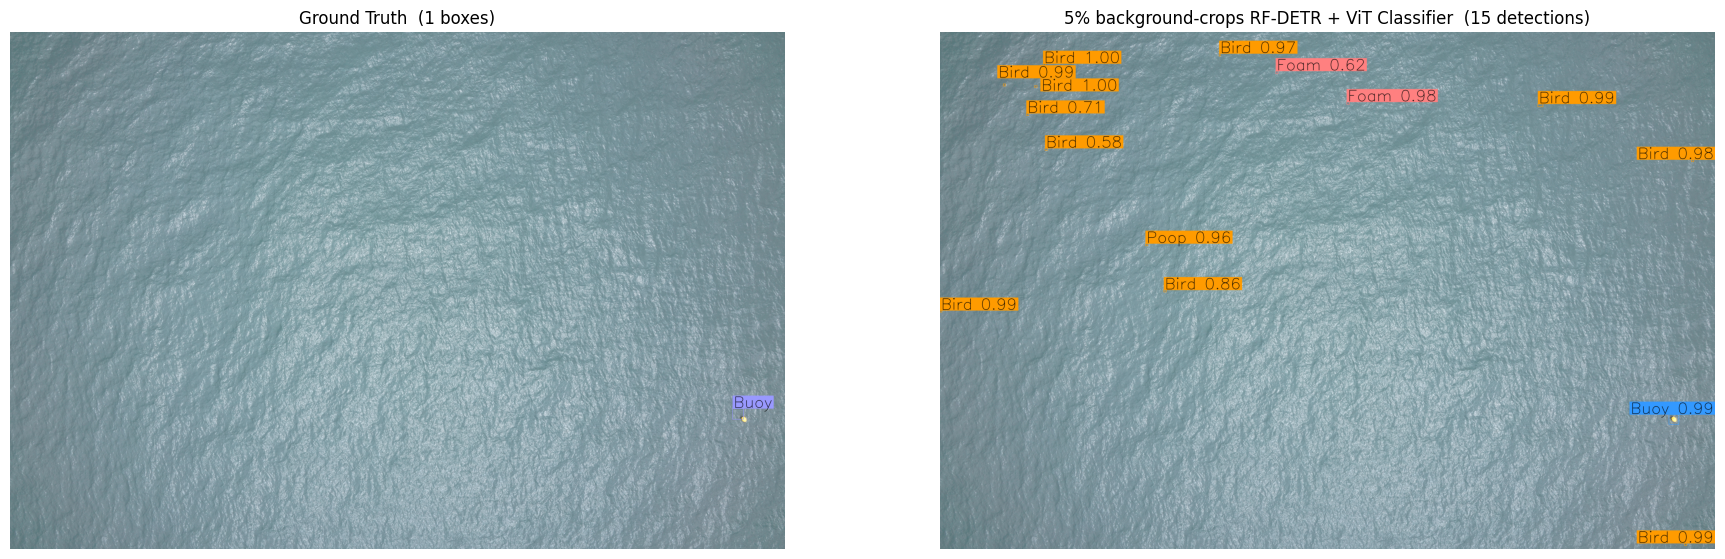

In [11]:
## Visualize — Ground Truth vs RF-DETR + ViT prediction

import cv2

# Shown in the prediction panel title in place of "Medium", e.g.:
# "0% background", "5% background", "10% background", "20% background"
BACKGROUND_PCT = "5% background-crops"

color = sv.ColorPalette.from_hex([
    '#ffff00', '#ff9b00', '#ff66ff', '#3399ff', '#ff66b2', '#ff8080',
    '#b266ff', '#9999ff', '#66ffff', '#33ff99', '#66ff66', '#99ff00'
])
text_scale     = sv.calculate_optimal_text_scale(resolution_wh=image_pil.size)  # back to normal size
text_thickness = 3  # bolder text
thickness      = sv.calculate_optimal_line_thickness(resolution_wh=image_pil.size)

bbox_ann  = sv.BoxAnnotator(color=color, thickness=thickness)
label_ann = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    text_thickness=text_thickness,
    text_padding=10,
    smart_position=True,   # keeps labels inside the image bounds and avoids overlap
)

# Ground truth
gt_img = cv2.cvtColor(np.array(image_pil.copy()), cv2.COLOR_RGB2BGR)
if len(gt) > 0:
    gt_text = [
        DETECTOR_CLASSES[c] if DETECTOR_CLASSES and c < len(DETECTOR_CLASSES) else f'class_{c}'
        for c in gt.class_id
    ]
    gt_img = bbox_ann.annotate(gt_img, gt)
    gt_img = label_ann.annotate(gt_img, gt, gt_text)

# Prediction
pred_img = cv2.cvtColor(np.array(image_pil.copy()), cv2.COLOR_RGB2BGR)
if len(detections) > 0:
    pred_text = [f'{lbl} {scr:.2f}' for lbl, scr in zip(clf_labels, clf_scores)]
    pred_img = bbox_ann.annotate(pred_img, detections)
    pred_img = label_ann.annotate(pred_img, detections, pred_text)

sv.plot_images_grid(
    images=[gt_img, pred_img],
    grid_size=(1, 2),
    titles=[
        f'Ground Truth  ({len(gt)} boxes)',
        f'{BACKGROUND_PCT} RF-DETR + ViT Classifier  ({len(detections)} detections)',
    ],
    size=(22, 11),
)

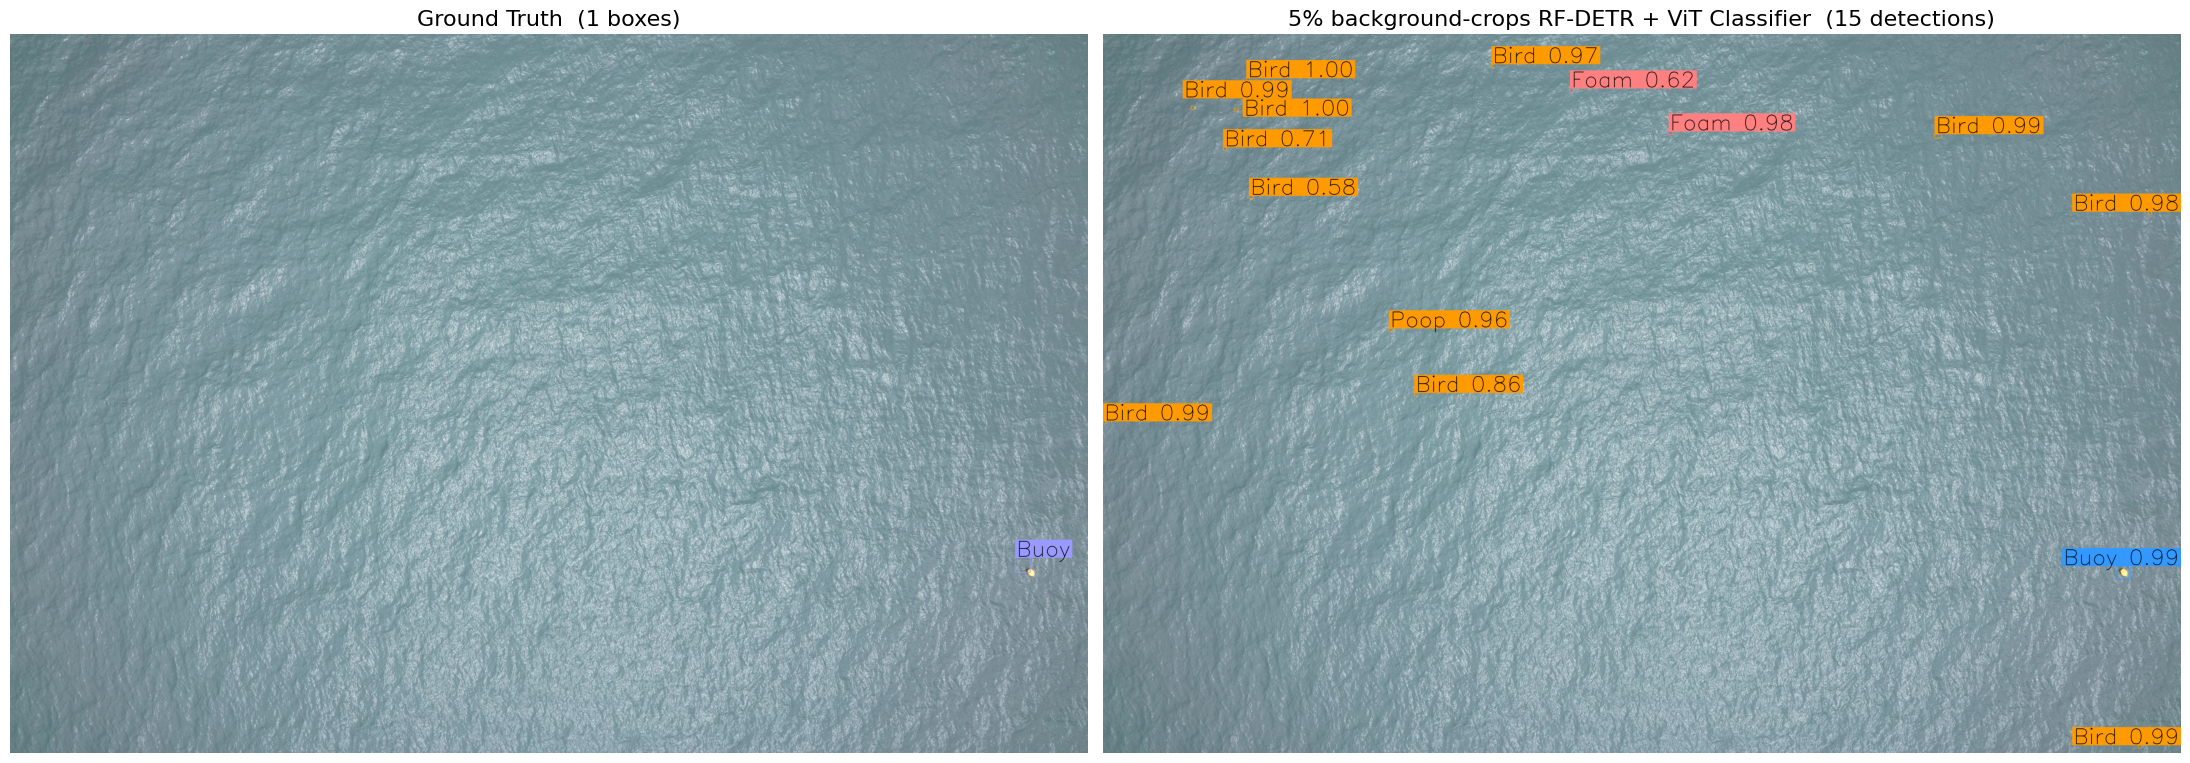

Saved → /content/drive/MyDrive/rfdetr-backgrounds/predictions/trinity-1_20230607T194614_DSC00188__5pct-background-crops.png  (3.6 MB)


In [12]:
## Save the GT vs prediction figure to Drive

import os, re, cv2
import matplotlib.pyplot as plt

SAVE_DIR = "/content/drive/MyDrive/rfdetr-backgrounds/predictions"
os.makedirs(SAVE_DIR, exist_ok=True)

# Filename carries the source image + the background-crop setting,
# so runs at different percentages don't overwrite each other.
stem = os.path.splitext(os.path.basename(IMAGE_PATH))[0]
tag  = re.sub(r"[^A-Za-z0-9._-]+", "-", BACKGROUND_PCT.replace("%", "pct")).strip("-")
OUT_PATH = os.path.join(SAVE_DIR, f"{stem}__{tag}.png")

titles = [
    f"Ground Truth  ({len(gt)} boxes)",
    f"{BACKGROUND_PCT} RF-DETR + ViT Classifier  ({len(detections)} detections)",
]

fig, axes = plt.subplots(1, 2, figsize=(22, 11))
for ax, img, title in zip(axes, [gt_img, pred_img], titles):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))   # gt_img/pred_img are BGR
    ax.set_title(title, fontsize=16)
    ax.axis("off")

fig.tight_layout()
fig.savefig(OUT_PATH, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved → {OUT_PATH}  ({os.path.getsize(OUT_PATH) / 1e6:.1f} MB)")